In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.isna()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
41996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
41997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
41998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [7]:
df.isna().sum()

label       0
pixel0      0
pixel1      0
pixel2      0
pixel3      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Length: 785, dtype: int64

In [9]:
y = df['label']

In [11]:
df.shape

(42000, 785)

In [12]:
y.shape

(42000,)

In [15]:
x = df.drop(columns=['label'])

In [16]:
x.shape

(42000, 784)

In [17]:
x.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
y.head()

0    1
1    0
2    1
3    4
4    0
Name: label, dtype: int64

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
x_train, x_val, y_train, y_val = train_test_split(x, y, random_state=42)

In [22]:
x_train.shape

(31500, 784)

In [23]:
x_val.shape

(10500, 784)

In [24]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


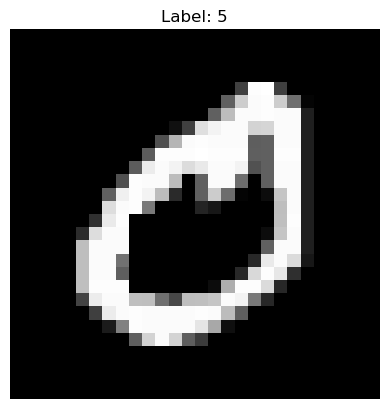

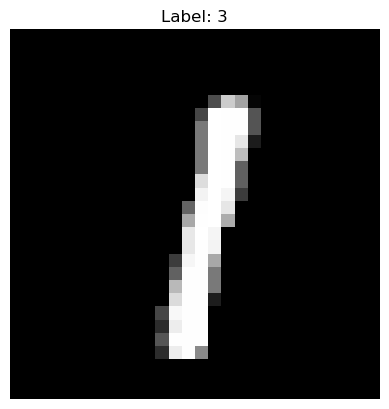

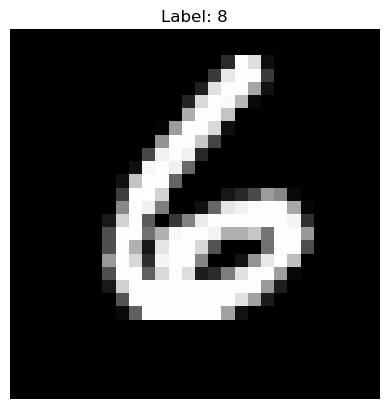

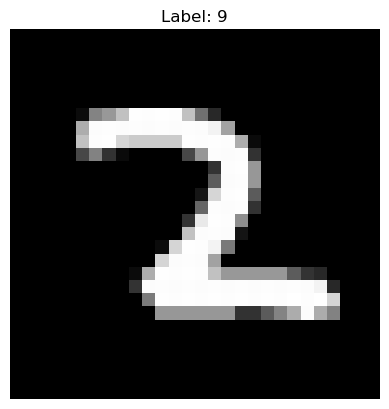

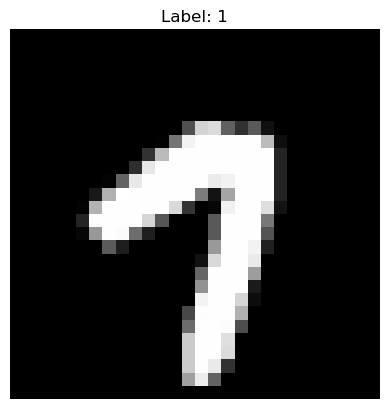

In [31]:
idx = 7
for i in range(5):
    img = x_train.iloc[idx].values.reshape(28, 28)
    idx+=1
    plt.imshow(img, cmap="gray")
    plt.title(f"Label: {y.iloc[idx]}")
    plt.axis("off")
    plt.show()

In [32]:
df_test = pd.read_csv('test.csv')

In [33]:
df_test.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [34]:
df_test.shape

(28000, 784)

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [61]:
clf = LogisticRegression(
    max_iter=2000,
    n_jobs=-1
)

clf.fit(x_train, y_train)

pred_val = clf.predict(x_val)

/Users/jimmy/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [62]:
print("Score for Logistic Regression:",(accuracy_score(y_val, pred_val)))

Score for Logistic Regression: 0.8972380952380953


In [42]:
svm = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),  # sparse-safe-ish; OK for dense too
    ("model", LinearSVC(C=2.0))
])

In [43]:
svm.fit(x_train, y_train)

/Users/jimmy/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,False
,with_std,True
,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001


In [58]:
pred_val = svm.predict(x_val)

In [59]:
print("Score for SVM:",(accuracy_score(y_val, pred_val)))

Score for SVM: 0.9057142857142857


In [48]:
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

rf.fit(x_train, y_train)  

,n_estimators,400
,criterion,'gini'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [49]:
pred_val = rf.predict(x_val)

In [56]:
print("Score for Random Forest:",(accuracy_score(y_val, pred_val)))

Score for Random Forest: 0.8912380952380953


### Try to do CNN

In [63]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 13, 13, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 5, 5, 64)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 1600)              0         
                                                                 
 dense (Dense)               (None, 128)               2

In [70]:
x_train = x_train.to_numpy()

# normalize
x_train = x_train.astype("float32") / 255.0

# reshape for CNN
x_train = x_train.reshape(-1, 28, 28, 1)

print(x_train.shape)

AttributeError: 'numpy.ndarray' object has no attribute 'to_numpy'

In [72]:
print(y_train.shape, y_train.dtype)
print(np.unique(y_train))

(31500,) int64
[0 1 2 3 4 5 6 7 8 9]


In [73]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [74]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)


Epoch 1/10
443/443 [==============================] - 3s 6ms/step - loss: 2.3020 - accuracy: 0.1117 - val_loss: 2.3017 - val_accuracy: 0.1108
Epoch 2/10
443/443 [==============================] - 3s 6ms/step - loss: 2.3016 - accuracy: 0.1125 - val_loss: 2.3018 - val_accuracy: 0.1108
Epoch 3/10
443/443 [==============================] - 3s 6ms/step - loss: 2.3016 - accuracy: 0.1125 - val_loss: 2.3017 - val_accuracy: 0.1108
Epoch 4/10
443/443 [==============================] - 3s 6ms/step - loss: 2.3016 - accuracy: 0.1125 - val_loss: 2.3017 - val_accuracy: 0.1108
Epoch 5/10
443/443 [==============================] - 3s 6ms/step - loss: 2.3015 - accuracy: 0.1125 - val_loss: 2.3018 - val_accuracy: 0.1108
Epoch 6/10
443/443 [==============================] - 3s 6ms/step - loss: 2.3015 - accuracy: 0.1125 - val_loss: 2.3017 - val_accuracy: 0.1108
Epoch 7/10
443/443 [==============================] - 3s 6ms/step - loss: 2.3016 - accuracy: 0.1125 - val_loss: 2.3018 - val_accuracy: 0.1108
Epoch 

In [78]:
x_val = x_val.to_numpy().astype("float32") / 255.0
x_val = x_val.reshape(-1, 28, 28, 1)

In [87]:
pred_val = model.predict(x_val)

329/329 [==============================] - 0s 1ms/step


In [88]:
y_val  = np.argmax(y_val)

In [89]:
accuracy_score(y_val, pred_val)

InvalidParameterError: The 'y_true' parameter of accuracy_score must be an array-like or a sparse matrix. Got 2 instead.